# 03 - Modeling | B3 Quant Analytics

Notebook de demonstração: treinamento, avaliação e interpretação do modelo de previsão de retorno diário (t+1).

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.append(str(PROJECT_ROOT / "src"))

from models.train import train_return_model
from models.predict import predict_next_return
from models.evaluate import evaluate_predictions
from models.registry import save_model

df = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "features.csv", parse_dates=["date"])
df.head()

,date,adj_close,close,high,low,open,volume,ticker,daily_return,log_return,volatility_rolling,var_historical_rolling,sharpe_ratio,adf_pvalue
0,2020-01-02,19.295866,28.181818,28.181818,27.197596,27.445530,25031584.0,BBDC4.SA,NaN,NaN,NaN,NaN,-0.362413,9.177839e-18
1,2020-01-03,19.305624,28.181818,28.549961,27.708488,27.723516,39999078.0,BBDC4.SA,0.000000,0.000000,NaN,NaN,-0.362413,9.177839e-18
2,2020-01-06,18.960789,27.678436,28.009014,27.377910,27.948910,33675497.0,BBDC4.SA,-0.017862,-0.018023,NaN,NaN,-0.362413,9.177839e-18
3,2020-01-07,18.631401,27.197596,27.768595,27.047333,27.610819,19775066.0,BBDC4.SA,-0.017372,-0.017525,NaN,NaN,-0.362413,9.177839e-18
4,2020-01-08,18.343176,26.776860,27.438017,26.641623,27.325320,28306110.0,BBDC4.SA,-0.015470,-0.015591,NaN,NaN,-0.362413,9.177839e-18


In [2]:
artifacts = train_return_model(df)
pred = predict_next_return(artifacts.model, artifacts.x_test, artifacts.feature_columns)
metrics = evaluate_predictions(artifacts.y_test.to_numpy(), pred)

pd.DataFrame([metrics]).round(4)

,rmse,mae,r2,directional_accuracy
0,0.0191,0.0139,-0.0022,0.4873


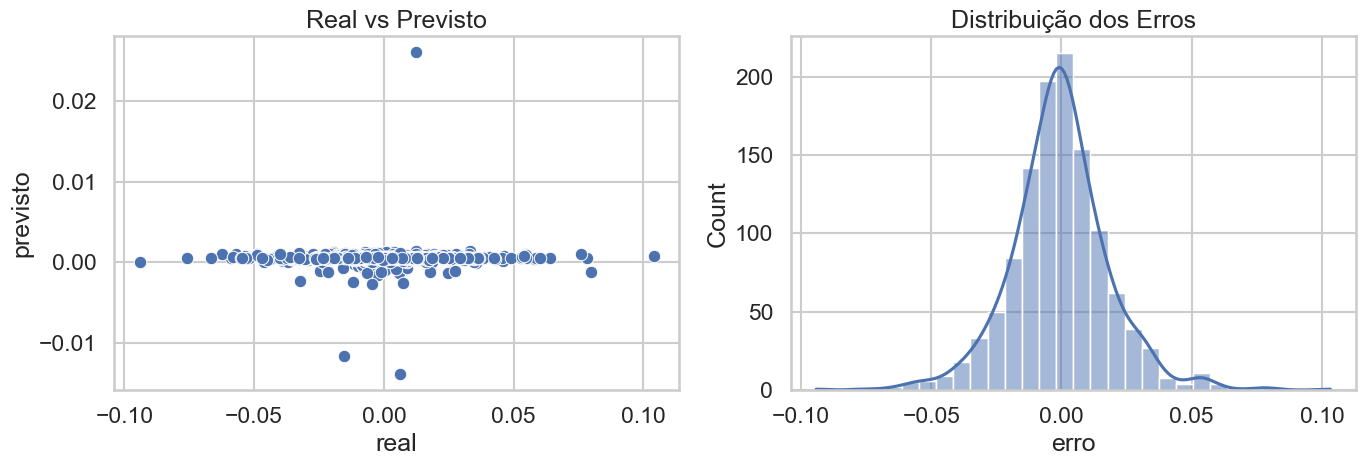

,erro,acerto_direcional
0,0.032540,True
1,0.011052,True
2,0.003773,True
3,-0.009128,False
4,-0.015052,False


In [3]:
results = pd.DataFrame({"real": artifacts.y_test.to_numpy(), "previsto": pred})
results["erro"] = results["real"] - results["previsto"]
results["acerto_direcional"] = np.sign(results["real"]) == np.sign(results["previsto"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=results, x="real", y="previsto", ax=axes[0])
axes[0].set_title("Real vs Previsto")

sns.histplot(results["erro"], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Distribuição dos Erros")

plt.tight_layout()
plt.show()

results[["erro", "acerto_direcional"]].head()

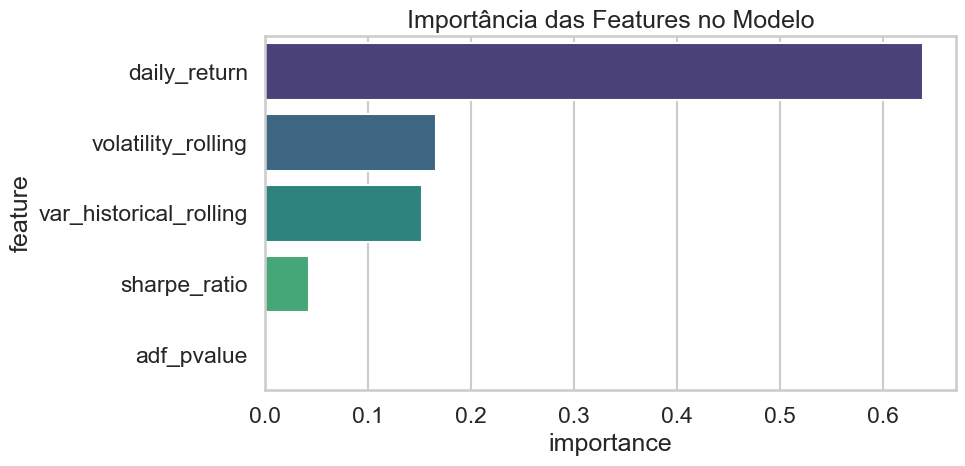

,feature,importance
0,daily_return,0.639198
1,volatility_rolling,0.165875
2,var_historical_rolling,0.152580
3,sharpe_ratio,0.042348
4,adf_pvalue,0.000000


In [4]:
importances = pd.DataFrame(
    {"feature": artifacts.feature_columns, "importance": artifacts.model.feature_importances_}
).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=importances, x="importance", y="feature", palette="viridis", hue="feature", legend=False)
plt.title("Importância das Features no Modelo")
plt.tight_layout()
plt.show()

importances

In [5]:
model_dir = PROJECT_ROOT / "models"
model_path, metadata_path = save_model(
    model=artifacts.model,
    feature_columns=artifacts.feature_columns,
    metrics=metrics,
    output_dir=model_dir,
)

latest_per_ticker = df.sort_values(["ticker", "date"]).groupby("ticker", as_index=False).tail(1)

latest_per_ticker = latest_per_ticker.dropna(subset=artifacts.feature_columns)
latest_per_ticker["pred_return_t1"] = predict_next_return(
    artifacts.model, latest_per_ticker, artifacts.feature_columns
)

latest_per_ticker[["ticker", "date", "pred_return_t1"]]

,ticker,date,pred_return_t1
1493,BBDC4.SA,2025-12-30,0.000489
2987,ITUB4.SA,2025-12-30,0.000497
4481,PETR4.SA,2025-12-30,0.000483
5975,VALE3.SA,2025-12-30,0.000492


## Tópicos de discussão
- Começo por métricas clássicas (RMSE, MAE, R²) e depois enfatizo **acurácia direcional**, útil para decisão de trading.
- Uso importância de features para explicar o comportamento do modelo de forma interpretável.
- Fecho mostrando inferência por ticker e persistência de artefatos, reforçando maturidade de produção.